In [1]:
import polars as pl
import matplotlib.pyplot as plt

In [3]:
# odaiデータの読み込み
odai_df = pl.read_parquet("BoketeDBv3/odai_db/")

# OCRを実施済みかつ、文字が検出されなかったデータを抽出
odai_df = odai_df.filter(
    (pl.col("imageOCR").is_not_null()) &
    (pl.col("imageOCR").list.len() == 0)
)
print(odai_df.shape)

# 現実画像に対するスコアを抽出する式
real_life_score = (
    pl.col("imageType")
    .list.eval(
        pl.element()
        .filter(pl.element().struct.field("key") == "a real life photograph")
        .struct.field("value")
    )
    .list.first()
)

# 各画像タイプの最大スコアを抽出する式
row_max_score = (
    pl.col("imageType")
    .list.eval(pl.element().struct.field("value"))
    .list.max()
)

odai_df = odai_df.filter(
    real_life_score == row_max_score
)
print(odai_df.shape)
odai_df

(4050274, 8)
(1720463, 8)


id,date,bokeCount,category,largeUrl,imageOCR,imageCaption,imageType
i64,datetime[ms],i32,str,str,list[struct[5]],str,list[struct[2]]
5,2008-09-05 04:15:53,9,"""動物""","""https://d13n9ry8xcpemi.cloudfr…",[],"""乾燥した草地に立つ、小さな鹿が草を食べている。""","[{""a real life photograph"",0.762576}, {""an anime screenshot"",0.007475}, … {""a traditional artwork"",0.226634}]"
6,2008-09-05 04:17:13,27,"""人物""","""https://d13n9ry8xcpemi.cloudfr…",[],"""野球のピッチャーが、ボールを投げる瞬間の姿。""","[{""a real life photograph"",0.92303}, {""an anime screenshot"",0.061268}, … {""a traditional artwork"",0.014777}]"
7,2008-09-05 04:19:23,10,"""人物""","""https://d13n9ry8xcpemi.cloudfr…",[],"""リングの角に立つ、赤いマットの手袋をはめた拳手が、上を向いて…","[{""a real life photograph"",0.782882}, {""an anime screenshot"",0.075567}, … {""a traditional artwork"",0.139653}]"
9,2008-09-05 04:23:17,28,"""人物""","""https://d13n9ry8xcpemi.cloudfr…",[],"""裸の上半身をした男性が、木々の間の砂地に立っている。""","[{""a real life photograph"",0.92842}, {""an anime screenshot"",0.028737}, … {""a traditional artwork"",0.040245}]"
12,2008-09-05 04:26:23,75,"""人物""","""https://d13n9ry8xcpemi.cloudfr…",[],"""男性が、緑色のポールに立って、森のなかで笑っています。""","[{""a real life photograph"",0.933999}, {""an anime screenshot"",0.014722}, … {""a traditional artwork"",0.0512}]"
…,…,…,…,…,…,…,…
989978,2014-09-24 18:39:26,7,"""人物""","""https://d2dcan0armyq93.cloudfr…",[],"""屋外の駐車場に、オレンジ色の服を着た女性と、青いスーツを着た…","[{""a real life photograph"",0.820954}, {""an anime screenshot"",0.065761}, … {""a traditional artwork"",0.102079}]"
989981,2014-09-24 18:41:12,10,"""人物""","""https://d2dcan0armyq93.cloudfr…",[],"""黄色い車の窓から顔を出た男性が、笑顔で手を挙げています。""","[{""a real life photograph"",0.829377}, {""an anime screenshot"",0.033783}, … {""a traditional artwork"",0.116367}]"
989982,2014-09-24 18:41:13,13,"""人物2人以上""","""https://d2dcan0armyq93.cloudfr…",[],"""野球の試合中のバッティング席で、1人の選手が膝をつき、手を伸…","[{""a real life photograph"",0.971889}, {""an anime screenshot"",0.00513}, … {""a traditional artwork"",0.020145}]"


In [4]:
# bokeデータの読み込み
boke_df = pl.read_parquet("BoketeDBv3/boke_db/")

# フィルタリング済みのodaiデータと結合
boke_df = boke_df.join(
    odai_df.select("id"),          # お題側は id 列だけがあれば十分なので軽量化
    left_on="odaiId",              # boke_df 側の結合キー
    right_on="id",                 # odai_df 側の結合キー
    how="inner"                    # 両方に存在するデータだけを残す（インナー・ジョイン）
)
print(boke_df.shape)
boke_df

(18402330, 9)


id,odaiId,date,text,rateSum,rateCount,lastRateDate,category,rates
i64,i64,datetime[ms],str,f32,i32,datetime[ms],str,list[struct[2]]
114843616,5,2026-04-26 23:58:05,"""家、ついて行ってイイですか？""",3.0,1,null,"""シュール""",null
1512086,5,2011-06-04 13:40:41,"""こちらが見ていると微動だにしないが、よそ見をして視線を戻すと…",0.0,0,null,"""その他""",[]
52828,5,2008-09-26 17:06:42,"""ボクなんてさぁ～食べてもおいしくないよ。ね?だから今日は見逃…",3.0,1,null,"""その他""","[{2011-06-18 16:54:04,3.0}]"
52822,5,2008-09-26 17:04:44,"""ボクの学名、知ってますか？""",0.0,0,null,"""その他""",[]
52810,5,2008-09-26 17:01:37,"""くれるというならばそれはもう貰います""",3.0,1,null,"""その他""","[{2008-09-26 17:05:18,3.0}]"
…,…,…,…,…,…,…,…,…
24681296,989998,2014-09-24 18:58:22,"""海老蔵をぼこぼこにした人？""",0.0,0,null,"""バカ""",null
24681271,989998,2014-09-24 18:57:41,"""出歯んげリヨン""",0.0,0,null,"""バカ""",null
24681267,989998,2014-09-24 18:57:35,"""てめぇか、インドネシア産のコーヒー豆は。東南アジアのコーヒー…",0.0,0,null,"""バカ""",null


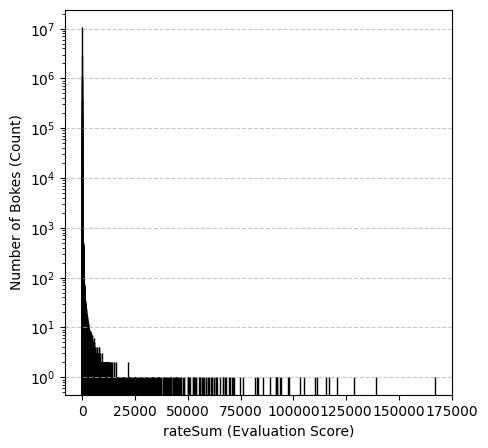

In [5]:
rate_distribution = (
    boke_df
    .group_by("rateSum")
    .agg(pl.len().alias("count"))
    .sort("rateSum")
)
pdf = rate_distribution.to_pandas()

plt.figure(figsize=(5, 5))
plt.bar(pdf["rateSum"], pdf["count"], width=1.0, color="skyblue", edgecolor="black")

plt.xlabel("rateSum (Evaluation Score)")
plt.ylabel("Number of Bokes (Count)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.yscale('log')

plt.show()

In [ ]:
# bokeデータの読み込み
boke_df = pl.read_parquet("BoketeDBv3/boke_db/")
print(boke_df.shape)    

# ratesがNullではないデータを抽出
boke_df = boke_df.filter(pl.col("rates").is_not_null())
print(boke_df.shape)    

(91907984, 9)
(4849954, 9)


In [10]:
list(sorted(set(boke_df["rateSum"].to_numpy().tolist())))

[0.0,
 1.0,
 2.0,
 3.0,
 4.0,
 5.0,
 6.0,
 7.0,
 8.0,
 9.0,
 10.0,
 11.0,
 12.0,
 13.0,
 14.0,
 15.0,
 16.0,
 17.0,
 18.0,
 19.0,
 20.0,
 21.0,
 22.0,
 23.0,
 24.0,
 25.0,
 26.0,
 27.0,
 28.0,
 29.0,
 30.0,
 31.0,
 32.0,
 33.0,
 34.0,
 35.0,
 36.0,
 37.0,
 38.0,
 39.0,
 40.0,
 41.0,
 42.0,
 43.0,
 44.0,
 45.0,
 46.0,
 47.0,
 48.0,
 49.0,
 50.0,
 51.0,
 52.0,
 53.0,
 54.0,
 55.0,
 56.0,
 57.0,
 58.0,
 59.0,
 60.0,
 61.0,
 62.0,
 63.0,
 64.0,
 65.0,
 66.0,
 67.0,
 68.0,
 69.0,
 70.0,
 71.0,
 72.0,
 73.0,
 74.0,
 75.0,
 76.0,
 77.0,
 78.0,
 79.0,
 80.0,
 81.0,
 82.0,
 83.0,
 84.0,
 85.0,
 86.0,
 87.0,
 88.0,
 89.0,
 90.0,
 91.0,
 92.0,
 93.0,
 94.0,
 95.0,
 96.0,
 97.0,
 98.0,
 99.0,
 100.0,
 101.0,
 102.0,
 103.0,
 104.0,
 105.0,
 106.0,
 107.0,
 108.0,
 109.0,
 110.0,
 111.0,
 112.0,
 113.0,
 114.0,
 115.0,
 116.0,
 117.0,
 118.0,
 119.0,
 120.0,
 121.0,
 122.0,
 123.0,
 124.0,
 125.0,
 126.0,
 127.0,
 128.0,
 129.0,
 130.0,
 131.0,
 132.0,
 133.0,
 134.0,
 135.0,
 136.0,
 137.0,
 138.0